<a href="https://colab.research.google.com/github/annabarsukovaca-stack/Machine-Learning-Practice/blob/main/Ch5updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
assert sys.version_info >= (3, 5)

import sklearn
assert sklearn.__version__ >= "0.20"

import numpy as np
import os

np.random.seed(42)

import matplotlib.pyplot as plt

In [2]:
#linear SVM classification (turning the problem into binary classification)
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]   # petal length, petal width

y = (iris["target"] == 2).astype(np.float64)

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(
        C=1,
        loss="hinge",
        random_state=42
    ))
])

svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

Always remember feature scaling when using SVMs

In [3]:
#where to save figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "svm"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [4]:
#linear SVM classification
from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)

X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

svm_clf = SVC(kernel="linear", C=float("inf"))
svm_clf.fit(X, y)

SVC(C=inf, kernel='linear')

In [5]:
#plot SVM decision boundary
x0 = np.linspace(0, 5.5, 200)

pred_1 = 5*x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

In [6]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]

    x0 = np.linspace(xmin, xmax, 200)

    decision_boundary = -w[0]/w[1] * x0 - b/w[1]

    margin = 1/w[1]

    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_

    plt.scatter(
        svs[:, 0],
        svs[:, 1],
        s=180,
        facecolors='#FFAAAA'
    )

    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k-", linewidth=2)
    plt.plot(x0, gutter_down, "k-", linewidth=2)

Saving figure large_margin_classification_plot


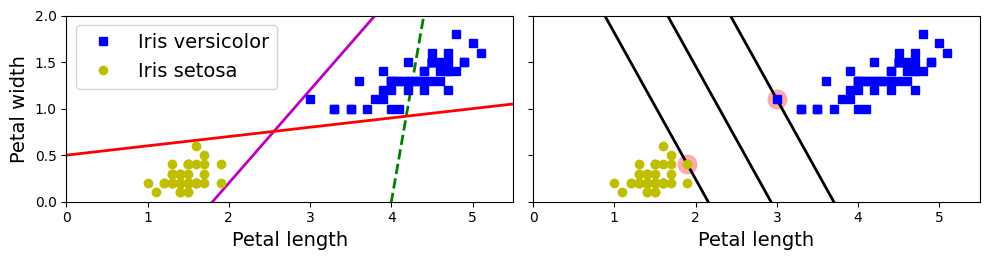

In [7]:
fig, axes = plt.subplots(
    ncols=2,
    figsize=(10, 2.7),
    sharey=True
)

plt.sca(axes[0])

plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)

plt.plot(
    X[:, 0][y == 1],
    X[:, 1][y == 1],
    "bs",
    label="Iris versicolor"
)

plt.plot(
    X[:, 0][y == 0],
    X[:, 1][y == 0],
    "yo",
    label="Iris setosa"
)

plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 5.5, 0, 2])

plt.sca(axes[1])

plot_svc_decision_boundary(svm_clf, 0, 5.5)

plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs")
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo")

plt.xlabel("Petal length", fontsize=14)
plt.axis([0, 5.5, 0, 2])

save_fig("large_margin_classification_plot")
plt.show()

In [8]:
#feature scaling
Xs = np.array([
    [1, 50],
    [5, 20],
    [3, 80],
    [5, 60]
]).astype(np.float64)

ys = np.array([0, 0, 1, 1])

svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)

SVC(C=100, kernel='linear')

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(Xs)

svm_clf.fit(X_scaled, ys)

SVC(C=100, kernel='linear')

In [10]:
#sof6t margin classification, linear SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]
y = (iris["target"] == 2).astype(np.float64)

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(
        C=1,
        loss="hinge",
        random_state=42
    )),
])

svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

In [11]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

In [12]:
#different C values
scaler = StandardScaler()

svm_clf1 = LinearSVC(
    C=1,
    loss="hinge",
    random_state=42
)

svm_clf2 = LinearSVC(
    C=100,
    loss="hinge",
    random_state=42
)

scaled_svm_clf1 = Pipeline([
    ("scaler", scaler),
    ("linear_svc", svm_clf1),
])

scaled_svm_clf2 = Pipeline([
    ("scaler", scaler),
    ("linear_svc", svm_clf2),
])

scaled_svm_clf1.fit(X, y)
scaled_svm_clf2.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc',
                 LinearSVC(C=100, loss='hinge', random_state=42))])

Imports + Iris data

In [13]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC, LinearSVR, SVR

In [14]:
iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris virginica

so, the task is binary
0 = not Virginica
1 = Virginica

Basic Linear SVM

In [15]:
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42))
])

svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

Pipeline automatically scales and features, trains the SVM

StandardScaler() is used because SVMs are sensitive to feature scale, so the features are putten on a similar scale

C1 controls the trade-off between both a wider margin and fewer margin violations

In [16]:
svm_clf.predict([[5.5, 1.7]])

array([1.])

the model predicts Iris Virginica

Nonlinear Classification: Polynomial Features + Linear SVM

In [20]:
from sklearn.datasets import make_moons

X, y = make_moons(
    n_samples=100,
    noise=0.15,
    random_state=42
)

make_moons
The two classes form curved half-moon shapes, so a simple straight line cannot separate them well.

creating the model:

In [21]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("scaler", StandardScaler()),
    ("svm_clf", LinearSVC(
        C=10,
        loss="hinge",
        random_state=42
    ))
])

polynomial_svm_clf.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge', random_state=42))])

The original data is nonlinear, but adding polynomial features can transform it into a space where a linear boundary can separate the classes

degree=3 means we create polynomial features up to degree 3

Polynomial Kernel

In [22]:
poly_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(
        kernel="poly",
        degree=3,
        coef0=1,
        C=5
    ))
])

poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

it can behave like adding polynomial features without explicitly creating all those features

In [23]:
poly100_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(
        kernel="poly",
        degree=10,
        coef0=100,
        C=5
    ))
])

poly100_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=100, degree=10, kernel='poly'))])

Gaussian RBF Kernel

In [24]:
rbf_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(
        kernel="rbf",
        gamma=5,
        C=0.001
    ))
])

rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=0.001, gamma=5))])

Compare gamma and C

In [25]:
gamma1, gamma2 = 0.1, 5
C1, C2 = 0.001, 1000

hyperparams = [
    (gamma1, C1),
    (gamma1, C2),
    (gamma2, C1),
    (gamma2, C2)
]

In [26]:
svm_clfs = []

for gamma, C in hyperparams:

    rbf_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(
            kernel="rbf",
            gamma=gamma,
            C=C
        ))
    ])

    rbf_kernel_svm_clf.fit(X, y)
    svm_clfs.append(rbf_kernel_svm_clf)

trained 4 RBF SVMs with different hyperparameters to see how gamma and C affect model complexity

Linear SVM Regression

In [27]:
np.random.seed(42)

m = 50

X = 2 * np.random.rand(m, 1)

y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

creates approximately linear data with some random noise

train SVM regressor:

In [28]:
svm_reg = LinearSVR(
    epsilon=1.5,
    random_state=42
)

svm_reg.fit(X, y)

LinearSVR(epsilon=1.5, random_state=42)

Unlike classification, SVM regression creates an epsilon-insentive tube around the prediction line. points inside the tube do not contribute to the error

compare different epsilon values

In [29]:
svm_reg1 = LinearSVR(
    epsilon=1.5,
    random_state=42
)

svm_reg2 = LinearSVR(
    epsilon=0.5,
    random_state=42
)

svm_reg1.fit(X, y)
svm_reg2.fit(X, y)

LinearSVR(epsilon=0.5, random_state=42)

to compare a wide epsilon tube with a narrow epsilon tube

Nonlinear SVM Regression

In [30]:
np.random.seed(42)

m = 100

X = 2 * np.random.rand(m, 1) - 1

y = (
    0.2
    + 0.1 * X
    + 0.5 * X**2
    + np.random.randn(m, 1) / 10
).ravel()

In [31]:
svm_poly_reg = SVR(
    kernel="poly",
    degree=2,
    C=100,
    epsilon=0.1,
    gamma="scale"
)

svm_poly_reg.fit(X, y)

SVR(C=100, degree=2, kernel='poly')

important parameters: kernel="poly" → polynomial kernel

degree=2 → quadratic relationship

C=100 → relatively weak regularization

epsilon=0.1 → tolerance around prediction

compare regulations in SVR

In [32]:
svm_poly_reg1 = SVR(
    kernel="poly",
    degree=2,
    C=100,
    epsilon=0.1,
    gamma="scale"
)

svm_poly_reg2 = SVR(
    kernel="poly",
    degree=2,
    C=0.01,
    epsilon=0.1,
    gamma="scale"
)

svm_poly_reg1.fit(X, y)
svm_poly_reg2.fit(X, y)

SVR(C=0.01, degree=2, kernel='poly')